# Part 1: Waste Image Classification Using Deep Learning

This notebook investigates the use of deep learning to classify waste images from the RealWaste dataset into nine categories.

Two approaches are developed and compared:
1. a custom Convolutional Neural Network (CNN) trained from scratch, and
2. VGG16 using transfer learning and selective fine-tuning.

The dataset is split into training, validation and test sets. The training set is used to learn model parameters, the validation set is used for model development and optimisation, and the test set is kept untouched until the final evaluation. Both final models use exactly the same data splits so that the comparison is fair.

**Dataset:** RealWaste  
**Source:** https://archive.ics.uci.edu/dataset/908/realwaste


## 1. Import Libraries

The required libraries are imported for file handling, image processing, data exploration, preprocessing, model training and evaluation.

In [ ]:
# Import the libraries and set a fixed random seed for reproducible results.
import os
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation,
    Rescaling
)

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess_input


# Set random seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Locate the Dataset

The RealWaste images are organised into separate folders according to their waste categories. The dataset is first downloaded and the folder containing the nine class directories is located before any analysis is carried out.

### 2.1 Download the Dataset

In [ ]:
# Download and extract the RealWaste dataset into the Colab workspace.
!wget -q https://archive.ics.uci.edu/static/public/908/realwaste.zip -O realwaste.zip
!unzip -q realwaste.zip -d realwaste_data

print("Dataset downloaded and extracted.")

Dataset downloaded and extracted.


In [ ]:
# Inspect the extracted folders to see the downloaded directory structure.
# Inspect downloaded folders
for root, dirs, files in os.walk("realwaste_data"):
    level = root.replace("realwaste_data", "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

realwaste_data/
    realwaste-main/
        RealWaste/


### 2.2 Locate the Image Folder

In [ ]:
# Search for the folder that contains all nine expected RealWaste class folders.
expected_classes = {
    "Cardboard",
    "Food Organics",
    "Glass",
    "Metal",
    "Miscellaneous Trash",
    "Paper",
    "Plastic",
    "Textile Trash",
    "Vegetation"
}

data_dir = None

for folder in Path("realwaste_data").rglob("*"):

    if folder.is_dir():

        subfolders = {
            f.name
            for f in folder.iterdir()
            if f.is_dir()
        }

        if expected_classes.issubset(subfolders):
            data_dir = folder
            break

print("Dataset folder:", data_dir)

if data_dir is None:
    raise FileNotFoundError("Could not locate the RealWaste class folders.")

Dataset folder: realwaste_data/realwaste-main/RealWaste


The image directory has been located successfully and will be used for the exploratory analysis and preprocessing steps that follow.

## 3. Exploratory Data Analysis

Before preprocessing and training, the dataset is explored to understand its class distribution and the visual characteristics of the images. This helps identify issues such as class imbalance and variation in object appearance that may affect model performance.


### 3.1 Identify Classes and Number of Images

The waste categories are identified from the folder names and the number of images in each category is counted. This gives an initial view of the dataset structure and whether the classes are evenly represented.

In [ ]:
# Read the class folders and collect the image filepaths for each waste category.
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_names = sorted([
    folder.name
    for folder in data_dir.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(class_names))
print("\nClasses:")

for class_name in class_names:
    print(class_name)

Number of classes: 9

Classes:
Cardboard
Food Organics
Glass
Metal
Miscellaneous Trash
Paper
Plastic
Textile Trash
Vegetation


In [ ]:
# Count the number of images in each class and store the results in a table.
class_counts = {}

for class_name in class_names:

    class_folder = data_dir / class_name

    image_files = [
        file
        for file in class_folder.rglob("*")
        if file.suffix.lower() in image_extensions
    ]

    class_counts[class_name] = len(image_files)


counts_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Number of Images"]
)

print("Total number of images:", counts_df["Number of Images"].sum())

counts_df

Total number of images: 4752


,Class,Number of Images
0,Cardboard,461
1,Food Organics,411
2,Glass,420
3,Metal,790
4,Miscellaneous Trash,495
5,Paper,500
6,Plastic,921
7,Textile Trash,318
8,Vegetation,436


The dataset contains 4,752 images across nine waste categories. The class counts are not equal, so the distribution is examined more closely before the data is split.


### 3.2 Analyse Class Distribution

The class counts are visualised with a bar chart so that any imbalance between the nine waste categories can be seen more clearly.

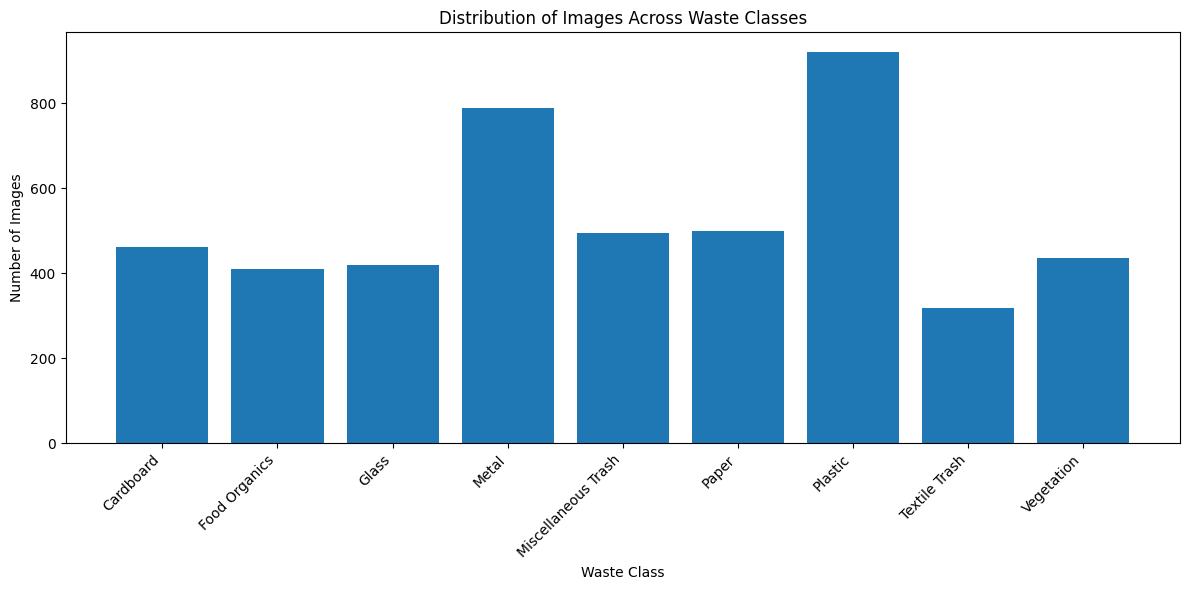

In [ ]:
# Plot the number of images in each waste category.
plt.figure(figsize=(12, 6))

plt.bar(
    counts_df["Class"],
    counts_df["Number of Images"]
)

plt.title("Distribution of Images Across Waste Classes")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
# Find the largest and smallest classes and calculate the imbalance ratio.
largest_class = counts_df.loc[
    counts_df["Number of Images"].idxmax()
]

smallest_class = counts_df.loc[
    counts_df["Number of Images"].idxmin()
]

imbalance_ratio = (
    largest_class["Number of Images"]
    / smallest_class["Number of Images"]
)

print(
    f"Largest class: {largest_class['Class']} "
    f"({largest_class['Number of Images']} images)"
)

print(
    f"Smallest class: {smallest_class['Class']} "
    f"({smallest_class['Number of Images']} images)"
)

print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Largest class: Plastic (921 images)
Smallest class: Textile Trash (318 images)
Imbalance ratio: 2.90:1


The class distribution is moderately imbalanced. Plastic is the largest class with 921 images, while Textile Trash is the smallest with 318 images, giving a largest-to-smallest ratio of about 2.90:1.

This imbalance is large enough to affect training if it is ignored. Stratified splitting is therefore used later to preserve the class proportions in each subset, while class weights are calculated from the training set so that mistakes on smaller classes have more influence during optimisation.


### 3.3 Display Sample Images

One image from each class is displayed to check that the labels have been loaded correctly and to get a quick visual sense of how the waste categories differ.

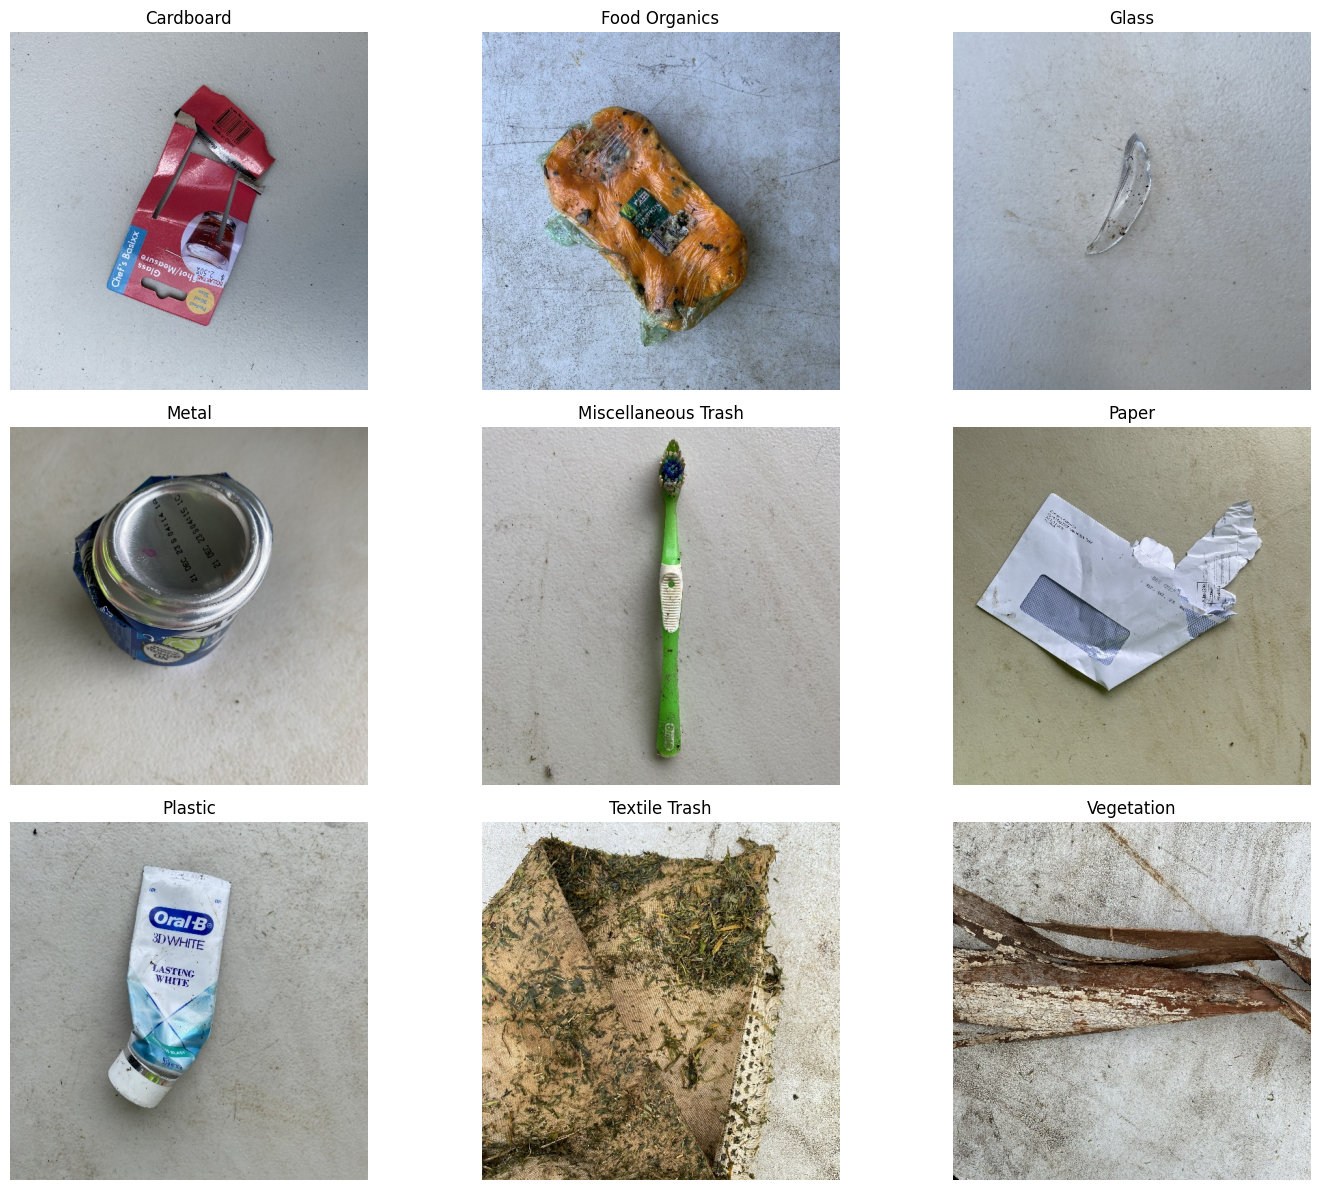

In [ ]:
# Display one sample image from each waste category.
plt.figure(figsize=(15, 12))

for i, class_name in enumerate(class_names):

    class_folder = data_dir / class_name

    image_files = [
        file
        for file in class_folder.rglob("*")
        if file.suffix.lower() in image_extensions
    ]

    selected_image = random.choice(image_files)

    image = Image.open(selected_image).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

The sample images show noticeable variation in object position, orientation, scale and appearance. Some classes also share similar visual characteristics. For example, Glass, Metal and Plastic can contain objects with similar shapes or reflective surfaces, while Miscellaneous Trash is visually much less consistent.

This means the models need to learn more than a single obvious feature. The variation also supports the use of moderate data augmentation during training.


## 4. Data Pre-processing

The dataset is prepared by checking image quality, detecting exact duplicates, creating stratified training/validation/test splits, encoding the labels and building a TensorFlow input pipeline.

The aim is not only to make the data usable by the models, but also to reduce avoidable data-quality problems and prevent data leakage. The same final splits are used for both the custom CNN and VGG16 so that their results can be compared fairly.


### 4.1 Check Image Integrity and Properties

Before preprocessing the images, each file is checked to ensure that it can be opened and verified as a valid image.

Pillow's `Image.open()` and `verify()` methods are used together with exception handling to identify corrupted or invalid image files. The original width, height and colour mode of each valid image are also recorded for further examination of the dataset.

In [ ]:
# Check every image for corruption and record its original size and colour mode.
# Corruption checking using
# Image.open(), verify(), and exception handling.

valid_images = []
corrupted_images = []

for class_name in class_names:

    class_folder = data_dir / class_name

    for file in class_folder.rglob("*"):

        if file.suffix.lower() in image_extensions:

            try:
                # Open the image file.
                with Image.open(file) as img:

                    # Record the original image properties.
                    width, height = img.size
                    colour_mode = img.mode

                    # Verify that the image file is valid.
                    img.verify()

                valid_images.append({
                    "filepath": str(file),
                    "label": class_name,
                    "width": width,
                    "height": height,
                    "colour_mode": colour_mode
                })

            except (IOError, SyntaxError):

                print("Bad file:", file.name)
                corrupted_images.append(str(file))


# Store information about all valid images.
df = pd.DataFrame(valid_images)

print("Valid images:", len(df))
print("Corrupted images:", len(corrupted_images))

Valid images: 4752
Corrupted images: 0


All 4,752 images were successfully opened and verified, and no corrupted files were found. Therefore, no samples need to be removed at this stage and the full dataset can be retained.


### 4.2 Inspect Image Dimensions and Colour Modes

The original image dimensions and colour modes are checked because images in the same training batch must ultimately have a consistent tensor shape.

In [ ]:
# Summarise the unique image dimensions and colour modes in the dataset.
print("Number of different image dimensions:")
print(
    df[["width", "height"]]
    .drop_duplicates()
    .shape[0]
)

print("\nMost common image dimensions:")
print(
    df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nColour modes:")
print(
    df["colour_mode"].value_counts()
)

Number of different image dimensions:
1

Most common image dimensions:
width  height
524    524       4752
dtype: int64

Colour modes:
colour_mode
RGB    4752
Name: count, dtype: int64


All 4,752 images have the same original resolution of 524 × 524 pixels and use RGB colour mode. This means there are no inconsistencies in image dimensions or number of channels.

The images are still resized to 224 × 224 pixels to reduce computation and to provide a common input size that is also compatible with VGG16. Every image is decoded explicitly as RGB so that the final input shape is `(224, 224, 3)`.


### 4.3 Check for Exact Duplicate Images

Exact duplicates are checked before the dataset is split. If the same image appears in both the training and test sets, the final evaluation could be misleading because the model may already have seen that image during training.

In [ ]:
# Create a SHA-256 hash function so exact duplicate files can be detected.
def calculate_file_hash(filepath, chunk_size=1024 * 1024):

    hash_object = hashlib.sha256()

    with open(filepath, "rb") as file:

        while True:

            chunk = file.read(chunk_size)

            if not chunk:
                break

            hash_object.update(chunk)

    return hash_object.hexdigest()

In [ ]:
# Calculate an image hash for every file and identify exact duplicates.
df["image_hash"] = df["filepath"].apply(
    calculate_file_hash
)

duplicate_mask = df.duplicated(
    subset="image_hash",
    keep="first"
)

duplicate_count = duplicate_mask.sum()

print("Exact duplicate images:", duplicate_count)

Exact duplicate images: 0


In [ ]:
# Remove exact duplicates only if any were found, then report the remaining sample count.
if duplicate_count > 0:

    print(
        f"Removing {duplicate_count} exact duplicate images."
    )

    df = (
        df.loc[~duplicate_mask]
        .reset_index(drop=True)
    )

else:

    print("No exact duplicate images need to be removed.")

print("Images remaining:", len(df))

No exact duplicate images need to be removed.
Images remaining: 4752


No exact duplicate images were found, so all 4,752 samples are retained.

This check is carried out before splitting because an identical image appearing in both the training and test sets would create data leakage and could make the final performance look better than it really is.


### 4.4 Stratified Train / Validation / Test Split

The cleaned dataset is divided into:

- 70% training data
- 15% validation data
- 15% test data

Stratified sampling is used so that each subset keeps approximately the same class proportions as the original dataset.

In [ ]:
# Create stratified 70/15/15 training, validation and test splits.
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(valid_df))
print("Testing images:", len(test_df))

Training images: 3326
Validation images: 713
Testing images: 713


The split produces 3,326 training images, 713 validation images and 713 test images.

The training set is used to learn the model parameters. The validation set is used to monitor generalisation and guide model-development decisions. The test set is kept separate until the final evaluation so that it remains an unbiased measure of performance on unseen data.


### 4.5 Verify Class Distribution After Splitting

The class counts in each subset are checked to confirm that stratification preserved the overall class distribution.

In [ ]:
# Compare class counts across the three data splits to verify stratification.
split_distribution = pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Validation": valid_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).sort_index()

split_distribution

,Train,Validation,Test
label,,,
Cardboard,323,69,69
Food Organics,288,61,62
Glass,294,63,63
Metal,553,119,118
Miscellaneous Trash,346,74,75
Paper,350,75,75
Plastic,645,138,138
Textile Trash,222,48,48
Vegetation,305,66,65


The class counts remain proportionally similar across the training, validation and test sets, confirming that stratification worked as intended. All nine classes are represented in every subset.

Using the same fixed splits for both models removes one possible source of unfairness from the later comparison.


### 4.6 Define Image Size, Batch Size and Class Labels

Both models use RGB images resized to 224 × 224 pixels, giving an input shape of `(224, 224, 3)`. This provides a consistent input size and is compatible with VGG16.

A batch size of 32 is used as a practical balance between memory usage and training efficiency.


In [ ]:
# Define the common image size, batch size and number of classes used by both models.
IMG_HEIGHT = 224
IMG_WIDTH = 224

IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

NUM_CLASSES = len(class_names)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 32
Number of classes: 9


### 4.7 Encode Class Labels

The text class names are converted into integer class IDs because the models require numerical target values during training.

In [ ]:
# Create the mapping between text class names and integer class IDs.
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

class_to_index

{'Cardboard': 0,
 'Food Organics': 1,
 'Glass': 2,
 'Metal': 3,
 'Miscellaneous Trash': 4,
 'Paper': 5,
 'Plastic': 6,
 'Textile Trash': 7,
 'Vegetation': 8}

In [ ]:
# Add the integer class ID to each training, validation and test dataframe.
train_df = train_df.copy()
valid_df = valid_df.copy()
test_df = test_df.copy()

train_df["label_id"] = (
    train_df["label"]
    .map(class_to_index)
    .astype("int32")
)

valid_df["label_id"] = (
    valid_df["label"]
    .map(class_to_index)
    .astype("int32")
)

test_df["label_id"] = (
    test_df["label"]
    .map(class_to_index)
    .astype("int32")
)

Each category is encoded as an integer from 0 to 8. This allows `sparse_categorical_crossentropy` to be used directly without converting the labels into one-hot vectors.


### 4.8 Calculate Class Weights

The dataset is moderately imbalanced, so balanced class weights are calculated using only the training labels.

Smaller classes receive larger weights and larger classes receive smaller weights. This changes how much each training example contributes to the loss and helps prevent the larger classes from dominating simply because they contain more images.

The same class weights are used for both models so that the imbalance is handled consistently.


In [ ]:
# Calculate balanced class weights from the training labels.
class_ids = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=train_df["label_id"].values
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, weights)
}

print("Class weights:")

for class_id, weight in class_weights.items():

    print(
        f"{class_names[class_id]:25s}: "
        f"{weight:.3f}"
    )

Class weights:
Cardboard                : 1.144
Food Organics            : 1.283
Glass                    : 1.257
Metal                    : 0.668
Miscellaneous Trash      : 1.068
Paper                    : 1.056
Plastic                  : 0.573
Textile Trash            : 1.665
Vegetation               : 1.212


The calculated weights reflect the class distribution. Textile Trash receives the largest weight (**1.665**) because it is the smallest class, while Plastic receives the smallest weight (**0.573**) because it is the largest class.

This gives errors on the smaller categories more influence during training without changing the validation or test distributions.


### 4.9 Load, Convert and Resize Images

Each image is read from disk, decoded as a three-channel RGB image and resized to 224 × 224 pixels.

The pixel values are deliberately left in the original 0–255 range at this stage because the custom CNN and VGG16 require different pixel preprocessing later.


In [ ]:
# Define how each image is read, decoded as RGB and resized to 224 x 224.
def load_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Define the RGB image shape
    image.set_shape([None, None, 3])

    # Resize all images to the same dimensions
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Convert to floating-point values
    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

### 4.10 Prepare TensorFlow Datasets for Model Training

The image filepaths and integer labels are converted into TensorFlow datasets.

The training dataset is shuffled so that the model does not repeatedly see samples in the same order. Validation and test data are left unshuffled to keep evaluation consistent. Batching and prefetching are then applied so that data can be supplied efficiently during training.


In [ ]:
# Build a reusable TensorFlow dataset pipeline with optional training-time shuffling.
AUTOTUNE = tf.data.AUTOTUNE


def create_dataset(dataframe, training=False):

    filepaths = dataframe["filepath"].values

    labels = dataframe[
        "label_id"
    ].values.astype("int32")

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [ ]:
# Create the training, validation and test TensorFlow datasets.
train_ds = create_dataset(
    train_df,
    training=True
)

valid_ds = create_dataset(
    valid_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

### 4.11 Data Augmentation

Data augmentation is applied only to the training images to introduce additional variation without collecting more labelled data.

The selected transformations are:

- rotation of approximately ±20°
- zoom of approximately 10%
- horizontal and vertical translation of approximately 10%
- horizontal flipping

These are the same main types of image augmentation introduced in Practical 3, with the rotation range increased from ±10° to ±20° for this dataset. Waste objects can naturally appear at different angles, so the slightly wider range introduces clearer orientation variation while still keeping the objects recognisable.

Vertical flipping is not used because it can reverse the natural top-bottom structure of the scene. Horizontal flipping is less disruptive while still changing object position and orientation.

Validation and test images are not augmented, so evaluation is performed on the original image distribution.


In [ ]:
# Define moderate training-time image augmentation.
data_augmentation = Sequential([

    # Approximately +/- 20 degrees
    RandomRotation(
        factor=20 / 360
    ),

    RandomZoom(
        height_factor=0.1,
        width_factor=0.1
    ),

    RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    ),

    RandomFlip(
        mode="horizontal"
    )

], name="data_augmentation")

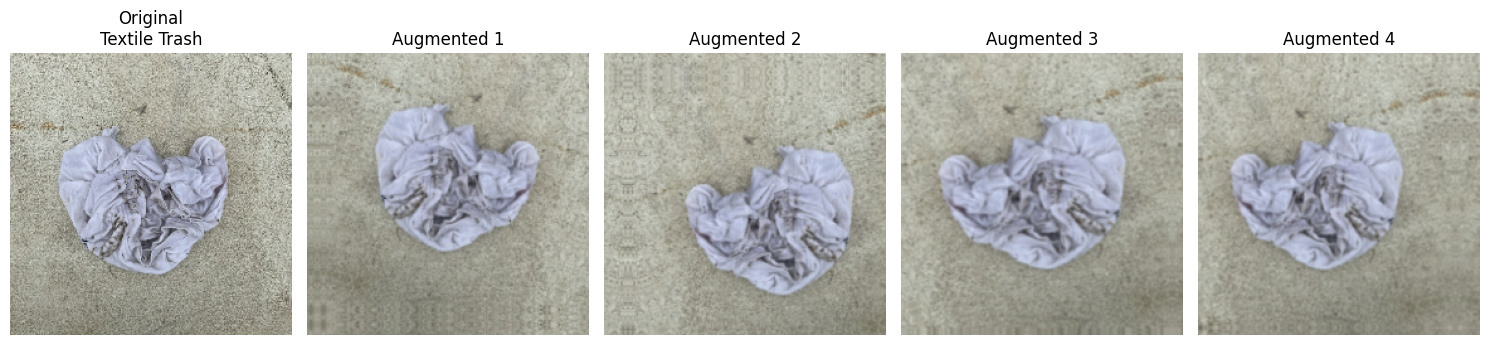

In [ ]:
# Visualise an original training image beside its augmented version.
# Verify that augmentation works

for images, labels in train_ds.take(1):

    original_image = images[0]
    original_label = labels[0].numpy()

    plt.figure(figsize=(15, 6))

    # Original
    plt.subplot(1, 5, 1)
    plt.imshow(
        tf.cast(
            original_image,
            tf.uint8
        )
    )
    plt.title(
        f"Original\n{class_names[original_label]}"
    )
    plt.axis("off")

    # Four randomly augmented versions
    for i in range(4):

        augmented_image = data_augmentation(
            tf.expand_dims(
                original_image,
                axis=0
            ),
            training=True
        )[0]

        plt.subplot(1, 5, i + 2)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(
                    augmented_image,
                    0,
                    255
                ),
                tf.uint8
            )
        )

        plt.title(
            f"Augmented {i + 1}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

The augmented examples show visible changes in angle, position and scale while the waste object remains recognisable. This suggests that the selected transformations add useful variation without changing the class meaning of the image.


### 4.12 Model-Specific Pixel Pre-processing

The two models use different pixel preprocessing:

- **Custom CNN:** pixel values are rescaled from 0–255 to 0–1.
- **VGG16:** `vgg16.preprocess_input()` is used so that the input matches the format expected by the ImageNet-pretrained weights.

The shared TensorFlow datasets therefore remain in the 0–255 floating-point range, with the correct preprocessing applied inside each model.


In [ ]:
# Define the pixel preprocessing used later by the custom CNN and VGG16.
# Used later inside the custom CNN
cnn_rescaling = Rescaling(
    1.0 / 255
)

### 4.13 Verify the Final Data Pipeline

One training batch is inspected to confirm the image and label shapes and to verify that the custom CNN rescaling behaves as expected.


In [ ]:
# Inspect one batch to confirm the final image and label shapes and pixel ranges.
for images, labels in train_ds.take(1):

    print(
        "Image batch shape:",
        images.shape
    )

    print(
        "Label batch shape:",
        labels.shape
    )

    print(
        "Raw minimum pixel value:",
        tf.reduce_min(images).numpy()
    )

    print(
        "Raw maximum pixel value:",
        tf.reduce_max(images).numpy()
    )

    cnn_images = cnn_rescaling(images)

    print(
        "\nCNN minimum after rescaling:",
        tf.reduce_min(cnn_images).numpy()
    )

    print(
        "CNN maximum after rescaling:",
        tf.reduce_max(cnn_images).numpy()
    )

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Raw minimum pixel value: 0.0
Raw maximum pixel value: 255.0

CNN minimum after rescaling: 0.0
CNN maximum after rescaling: 1.0


The final pipeline produces batches of shape `(32, 224, 224, 3)` with integer labels. Raw image values remain in the 0–255 range, while the custom CNN rescales them to 0–1 internally.

At this point, the dataset has been checked for corruption and duplicates, class imbalance has been handled, the splits have been verified, and the training-only augmentation pipeline is ready. Both models will use the same samples for a fair comparison.


## 5. Model 1 - Custom CNN Development

The first approach is a custom CNN trained entirely from scratch using the RealWaste training images.

A baseline model is trained first to establish a starting point. Its training behaviour and architecture are then examined to identify why it performs poorly. Based on this analysis, a more compact and better-controlled CNN is developed.

The baseline is kept as evidence of the model-development process, while the improved CNN is used as the final from-scratch model.


### 5.1 Baseline CNN Architecture

The baseline CNN follows the main structure introduced in Practical 3: convolutional layers for feature extraction, Batch Normalisation, max-pooling, Dropout, followed by a `Flatten` and Dense classification stage. The architecture is adapted for 224 × 224 RGB images and nine RealWaste classes.

This first model is intentionally kept as a baseline rather than being treated as the final design. Its training behaviour and parameter count are examined first so that any later architectural changes can be justified using actual results.


In [ ]:
# Build the baseline custom CNN architecture.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPool2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense,
    Rescaling,
    Activation,
    GlobalAveragePooling2D
)

tf.keras.utils.set_random_seed(SEED)

cnn_baseline = Sequential(
    name="Custom_CNN_Baseline"
)

cnn_baseline.add(
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
)

cnn_baseline.add(data_augmentation)
cnn_baseline.add(Rescaling(1./255))

# Block 1
cnn_baseline.add(
    Conv2D(
        32,
        (3, 3),
        strides=1,
        padding="same",
        activation="relu"
    )
)
cnn_baseline.add(BatchNormalization())
cnn_baseline.add(MaxPool2D((2, 2), strides=2, padding="same"))

# Block 2
cnn_baseline.add(
    Conv2D(
        64,
        (3, 3),
        strides=1,
        padding="same",
        activation="relu"
    )
)
cnn_baseline.add(Dropout(0.2))
cnn_baseline.add(BatchNormalization())
cnn_baseline.add(MaxPool2D((2, 2), strides=2, padding="same"))

# Block 3
cnn_baseline.add(
    Conv2D(
        128,
        (3, 3),
        strides=1,
        padding="same",
        activation="relu"
    )
)
cnn_baseline.add(BatchNormalization())
cnn_baseline.add(MaxPool2D((2, 2), strides=2, padding="same"))

# Original fully connected stage
cnn_baseline.add(Flatten())
cnn_baseline.add(Dense(128, activation="relu"))
cnn_baseline.add(Dropout(0.3))
cnn_baseline.add(Dense(NUM_CLASSES, activation="softmax"))

cnn_baseline.summary()


Model: "Custom_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,489 (49.36 MB)

 Trainable params: 12,940,041 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

### 5.2 Compile and Train the Baseline CNN

The baseline CNN contains approximately **12.94 million parameters**, with about **12.85 million** coming from the Dense layer after `Flatten`. This means roughly 99% of the model parameters are concentrated in the fully connected stage.

The model is trained for 10 epochs using Adam with a learning rate of 0.001. Sparse categorical crossentropy is used because the targets are integer class IDs, and the previously calculated class weights are included during training.

The test set is not used at this stage.


In [ ]:
# Compile the baseline CNN.
cnn_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the baseline CNN.
history_cnn_baseline = cnn_baseline.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - accuracy: 0.1597 - loss: 5.9215 - val_accuracy: 0.0884 - val_loss: 86.1351
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.1103 - loss: 2.2103 - val_accuracy: 0.0884 - val_loss: 96.2750
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.1230 - loss: 2.1895 - val_accuracy: 0.1066 - val_loss: 60.6052
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.1013 - loss: 2.1974 - val_accuracy: 0.1921 - val_loss: 14.8658
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.1073 - loss: 2.1715 - val_accuracy: 0.1907 - val_loss: 4.2302
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.1398 - loss: 2.1490 - val_accuracy: 0.1725 - val_loss: 2.3918
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.1049 - loss: 2.1656 - val_accuracy: 0.1417 - val_loss: 2.1837
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.1167 - los

### 5.3 Baseline Training Behaviour

The baseline CNN shows weak and inconsistent learning throughout the 10 epochs.

Training accuracy stays roughly between **10% and 16%**, which is close to the **11.11%** accuracy expected from uniform random guessing across nine classes. Validation accuracy is also unstable. It reaches a maximum of only **19.21% at epoch 4** and ends at **18.37%**, so there is no clear pattern of sustained improvement.

The loss values show the same problem. Validation loss is extremely high during the first few epochs, reaching **96.2750** at epoch 2 before falling sharply. By the final epochs, both training and validation loss are close to about 2.1–2.2, but this reduction in loss is not accompanied by useful classification accuracy.

This is not a normal overfitting pattern because the training accuracy itself remains very low. The baseline model is therefore failing to learn stable class-discriminating features, which suggests that simply adding more epochs is unlikely to solve the main problem.


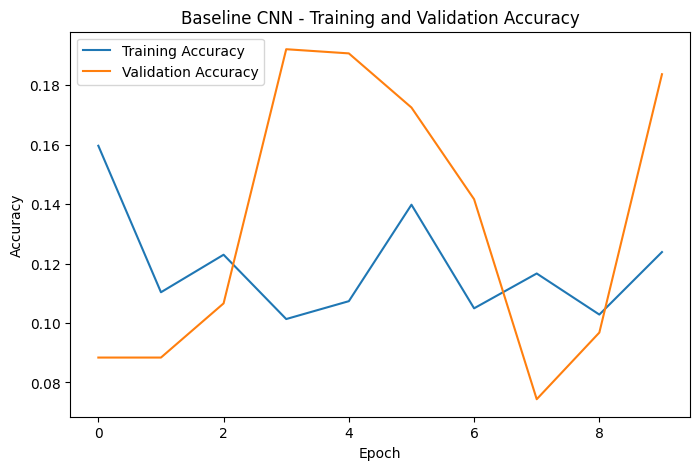

In [ ]:
# Plot baseline training and validation accuracy.
plt.figure(figsize=(8, 5))
plt.plot(
    history_cnn_baseline.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_cnn_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Baseline CNN - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


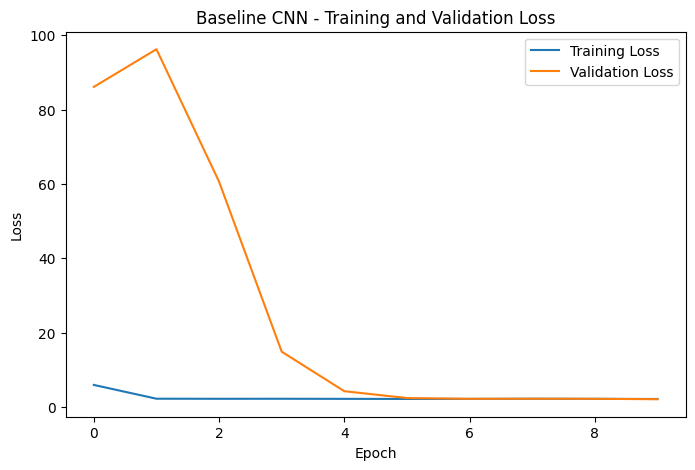

In [ ]:
# Plot baseline training and validation loss.
plt.figure(figsize=(8, 5))
plt.plot(
    history_cnn_baseline.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_cnn_baseline.history["val_loss"],
    label="Validation Loss"
)
plt.title("Baseline CNN - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


### 5.4 Baseline Architecture Diagnosis

The training curves suggest that the baseline CNN has an architectural and optimisation problem rather than simply needing more training epochs.

The model summary provides one likely explanation. After the final pooling layer, `Flatten` converts the feature maps into **100,352 values** before passing them to a Dense layer with 128 neurons. This Dense layer alone contains **12,845,184 parameters**, while the entire model contains **12,940,489 parameters**.

This means almost all of the model capacity is concentrated in the fully connected stage, even though only 3,326 training images are available. At the same time, the accuracy curves show that this large parameter count is not translating into effective learning.

The improved CNN therefore replaces `Flatten` with `GlobalAveragePooling2D`, reduces the size of the classification stage, and places more capacity in convolutional feature extraction. A lower learning rate and validation-based callbacks are also used to make optimisation more controlled.


### 5.5 Improved CNN Architecture and Training Strategy

The redesigned CNN makes several changes based directly on the baseline results:

- `GlobalAveragePooling2D` replaces `Flatten` to reduce the classification-stage parameter count.
- Additional convolutional layers are used so that more capacity is spent learning spatial image features.
- Batch normalisation is applied before ReLU activation.
- Dropout is retained as regularisation.
- The Adam learning rate is reduced from 0.001 to 0.0003 for smaller parameter updates.
- `ReduceLROnPlateau` lowers the learning rate when validation loss stops improving.
- `EarlyStopping` stops training when further improvement is not seen and restores the best validation weights.

A higher maximum of 30 epochs is used because the improved CNN has a lower learning rate and a deeper feature extractor, so it may require more epochs to converge than the baseline model.

However, training does not necessarily continue for all 30 epochs. `EarlyStopping` uses validation performance to determine when training should end and restores the best-performing weights. The test set remains untouched during this process.

In [ ]:
# Build the improved custom CNN.
tf.keras.utils.set_random_seed(SEED)

cnn_model = Sequential(
    name="Custom_CNN_Improved"
)

cnn_model.add(
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
)

cnn_model.add(data_augmentation)
cnn_model.add(Rescaling(1./255))

# Block 1
cnn_model.add(
    Conv2D(
        32,
        (3, 3),
        padding="same",
        use_bias=False
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(Activation("relu"))
cnn_model.add(MaxPool2D((2, 2), strides=2, padding="same"))

# Block 2
cnn_model.add(
    Conv2D(
        64,
        (3, 3),
        padding="same",
        use_bias=False
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(Activation("relu"))
cnn_model.add(MaxPool2D((2, 2), strides=2, padding="same"))

# Block 3
cnn_model.add(
    Conv2D(
        128,
        (3, 3),
        padding="same",
        use_bias=False
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(Activation("relu"))

cnn_model.add(
    Conv2D(
        128,
        (3, 3),
        padding="same",
        use_bias=False
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(Activation("relu"))
cnn_model.add(MaxPool2D((2, 2), strides=2, padding="same"))
cnn_model.add(Dropout(0.2))

# Block 4
cnn_model.add(
    Conv2D(
        256,
        (3, 3),
        padding="same",
        use_bias=False
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(Activation("relu"))
cnn_model.add(MaxPool2D((2, 2), strides=2, padding="same"))
cnn_model.add(Dropout(0.3))

# Compact classification stage
cnn_model.add(GlobalAveragePooling2D())
cnn_model.add(Dense(128, activation="relu"))
cnn_model.add(Dropout(0.4))
cnn_model.add(Dense(NUM_CLASSES, activation="softmax"))

cnn_model.summary()


Model: "Custom_CNN_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 571,881 (2.18 MB)

 Trainable params: 570,665 (2.18 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
# Compile the improved CNN and define validation-based callbacks.
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0003
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=cnn_callbacks,
    verbose=1
)


Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 28s 220ms/step - accuracy: 0.3897 - loss: 1.6425 - val_accuracy: 0.0884 - val_loss: 2.8068 - learning_rate: 3.0000e-04
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 199ms/step - accuracy: 0.4768 - loss: 1.3953 - val_accuracy: 0.0884 - val_loss: 4.4412 - learning_rate: 3.0000e-04
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5223 - loss: 1.3057
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 209ms/step - accuracy: 0.5289 - loss: 1.2842 - val_accuracy: 0.0940 - val_loss: 3.3697 - learning_rate: 3.0000e-04
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 208ms/step - accuracy: 0.5598 - loss: 1.1780 - val_accuracy: 0.2146 - val_loss: 2.2082 - learning_rate: 1.5000e-04
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 223ms/step - accuracy: 0.5827 - loss: 1.1287 - val_accuracy: 0.4937 - val_loss: 1.4371 - learning_rate: 1.5000e-04
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 215ms/st

### 5.6 Improved CNN Training Behaviour

The improved CNN learns much more effectively than the baseline. Training accuracy rises from **38.97% in epoch 1 to 65.09% by epoch 11**, while validation accuracy reaches a best value of **54.70% at epoch 6**.

The lowest validation loss is also reached at epoch 6, at **1.3478**. After this point, training accuracy continues to increase, but validation accuracy drops and validation loss becomes unstable. This indicates that the model begins to fit the training data more strongly without achieving the same improvement on unseen validation images.

`ReduceLROnPlateau` lowers the learning rate as validation loss stops improving, and `EarlyStopping` ends training at epoch 11. The weights from **epoch 6** are restored because that epoch produced the best validation loss.

This result shows why validation-based stopping is useful: the final model is not simply the weights from the last training epoch, but the version that generalised best during model development.


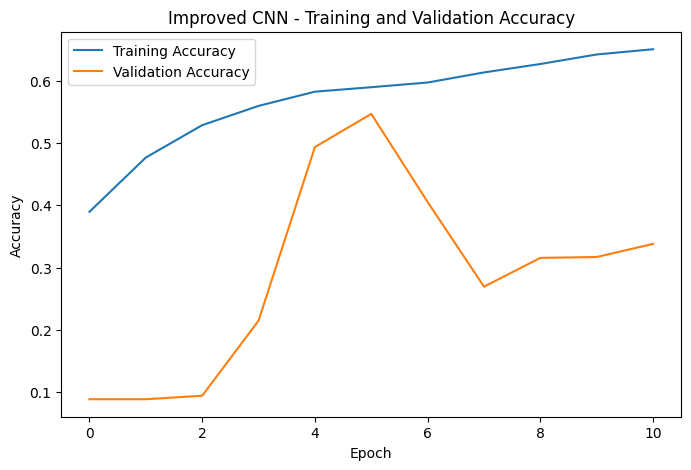

In [ ]:
# Plot improved CNN training and validation accuracy.
plt.figure(figsize=(8, 5))
plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Improved CNN - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


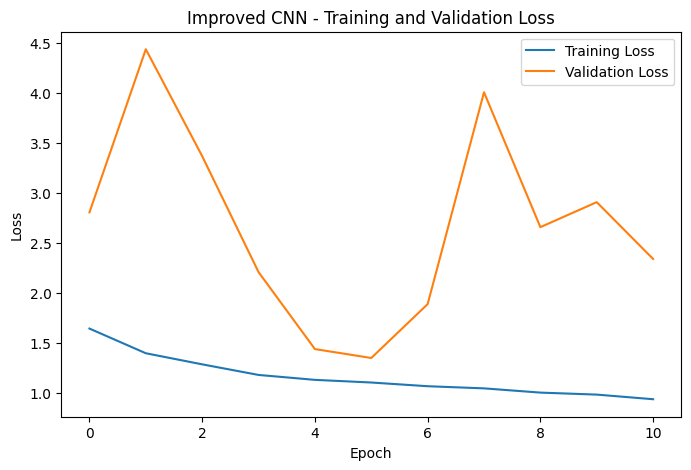

In [ ]:
# Plot improved CNN training and validation loss.
plt.figure(figsize=(8, 5))
plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)
plt.title("Improved CNN - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


### 5.7 Baseline vs Improved CNN

The following comparison measures whether the redesign achieved its two main goals: reducing unnecessary model complexity and improving validation performance.


In [ ]:
# Quantify the effect of the CNN redesign.
cnn_development_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Improved CNN"
    ],
    "Total Parameters": [
        cnn_baseline.count_params(),
        cnn_model.count_params()
    ],
    "Best Validation Accuracy": [
        max(history_cnn_baseline.history["val_accuracy"]),
        max(history_cnn.history["val_accuracy"])
    ],
    "Best Validation Loss": [
        min(history_cnn_baseline.history["val_loss"]),
        min(history_cnn.history["val_loss"])
    ]
})

parameter_reduction = (
    1 - cnn_model.count_params() / cnn_baseline.count_params()
) * 100

print(
    f"Parameter reduction from baseline to improved CNN: "
    f"{parameter_reduction:.2f}%"
)

cnn_development_df.round(4)


Parameter reduction from baseline to improved CNN: 95.58%


,Model,Total Parameters,Best Validation Accuracy,Best Validation Loss
0,Baseline CNN,12940489,0.1921,2.0730
1,Improved CNN,571881,0.5470,1.3478


The redesign produces a large improvement in both efficiency and validation performance.

The parameter count falls from **12,940,489 to 571,881**, which is a **95.58% reduction**. At the same time, best validation accuracy increases from **19.21% to 54.70%**, an improvement of **35.49 percentage points**, while best validation loss decreases from **2.0730 to 1.3478**.

Therefore, the much smaller model actually learns the task substantially better than the original baseline. This supports the decision to replace the parameter-heavy `Flatten` stage rather than simply increasing the number of training epochs.

However, a best validation accuracy of 54.70% also shows that learning all visual features from the RealWaste training images remains challenging. The improved CNN is retained as the final from-scratch model and provides a meaningful comparison against transfer learning.


## 6. Model 2 - VGG16 Transfer Learning

The second model uses VGG16 with ImageNet-pretrained weights.

This follows the transfer-learning approach introduced in Practical 5: VGG16 is loaded with `weights="imagenet"` and `include_top=False`, the pretrained convolutional base is initially frozen, and a new classifier is added for the target classes. The input is also prepared using the VGG16-specific preprocessing expected by the pretrained model.

The experiment is then extended with a second fine-tuning stage. First, only the new classifier is trained while the VGG16 base remains frozen. After this, only the highest convolutional block (`block5`) is unfrozen and updated using a much smaller learning rate.

This two-stage setup allows the notebook to measure how useful the pretrained ImageNet features are on their own, and then test whether adapting the higher-level features to RealWaste produces a further improvement.


### 6.1 Build the VGG16 Transfer Learning Model

The original VGG16 classification layers are removed using `include_top=False`, while the ImageNet-pretrained convolutional base is retained.

A new classifier is added using Global Average Pooling, a 128-neuron Dense layer, Dropout and a nine-class Softmax output.

During the first training stage, the entire VGG16 convolutional base is frozen. Therefore, only the new classifier is updated while the pretrained visual features remain unchanged.

In [ ]:
# Build the VGG16 transfer-learning model with a compact classifier.
from tensorflow import keras
from tensorflow.keras.applications import VGG16

# Load the pretrained convolutional base.
base_model = VGG16(
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False
)
base_model.trainable = False

inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Training-only augmentation.
x = data_augmentation(inputs)

# VGG16-specific ImageNet preprocessing.
x = keras.layers.Lambda(
    vgg16_preprocess_input,
    name="vgg16_preprocessing"
)(x)

# Frozen feature extractor.
x = base_model(
    x,
    training=False
)

# Compact classification head.
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(
    128,
    activation="relu"
)(x)
x = keras.layers.Dropout(0.3)(x)

outputs = keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

vgg16_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="VGG16_Transfer_Learning"
)

vgg16_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocessing (Lambda)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,513 (56.39 MB)

 Trainable params: 66,825 (261.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Confirm the frozen feature-extraction setup.
def count_trainable_parameters(model):
    return int(
        np.sum([
            np.prod(variable.shape)
            for variable in model.trainable_weights
        ])
    )

print("VGG16 base trainable:", base_model.trainable)
print("Total parameters:", vgg16_model.count_params())
print(
    "Trainable parameters in frozen stage:",
    count_trainable_parameters(vgg16_model)
)


VGG16 base trainable: False
Total parameters: 14781513
Trainable parameters in frozen stage: 66825


The model summary confirms that the frozen setup is working as intended. VGG16 has **14,781,513 total parameters**, but only **66,825 parameters (about 0.45%)** are trainable at this stage. The remaining 14.71 million pretrained parameters stay fixed while the new RealWaste classifier learns from the training data.


### 6.2 Frozen Transfer Learning

The frozen VGG16 model is trained using Adam with a learning rate of 0.0001.

A maximum of 15 epochs is used so that the newly added classifier has enough time to learn from the fixed VGG16 features. However, `EarlyStopping` monitors validation loss and can stop training earlier if further improvement is not observed.

`ReduceLROnPlateau` is also used to reduce the learning rate when validation loss stops improving.

Only the new classifier is trained in this stage, allowing the usefulness of the pretrained ImageNet features to be evaluated before any VGG16 convolutional weights are changed.

In [ ]:
# Compile and train the frozen VGG16 feature extractor.
vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_frozen_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_vgg16_frozen = vgg16_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=vgg_frozen_callbacks,
    verbose=1
)

# EarlyStopping has restored the best frozen-stage weights.
frozen_weights_path = "vgg16_frozen_best.weights.h5"
vgg16_model.save_weights(frozen_weights_path)

vgg_frozen_best_val_loss = min(
    history_vgg16_frozen.history["val_loss"]
)
vgg_frozen_best_val_accuracy = max(
    history_vgg16_frozen.history["val_accuracy"]
)


Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 31s 248ms/step - accuracy: 0.1936 - loss: 3.2344 - val_accuracy: 0.3072 - val_loss: 2.3568 - learning_rate: 1.0000e-04
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.3241 - loss: 2.1252 - val_accuracy: 0.4137 - val_loss: 1.8278 - learning_rate: 1.0000e-04
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.3942 - loss: 1.7367 - val_accuracy: 0.4755 - val_loss: 1.5635 - learning_rate: 1.0000e-04
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 189ms/step - accuracy: 0.4814 - loss: 1.5320 - val_accuracy: 0.5203 - val_loss: 1.4090 - learning_rate: 1.0000e-04
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.4826 - loss: 1.4129 - val_accuracy: 0.5456 - val_loss: 1.3038 - learning_rate: 1.0000e-04
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.5325 - loss: 1.2820 - val_accuracy: 0.5877 - val_loss: 1.2247 - learning_rate: 1.0000e-04
Epoch 7/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 19s 18

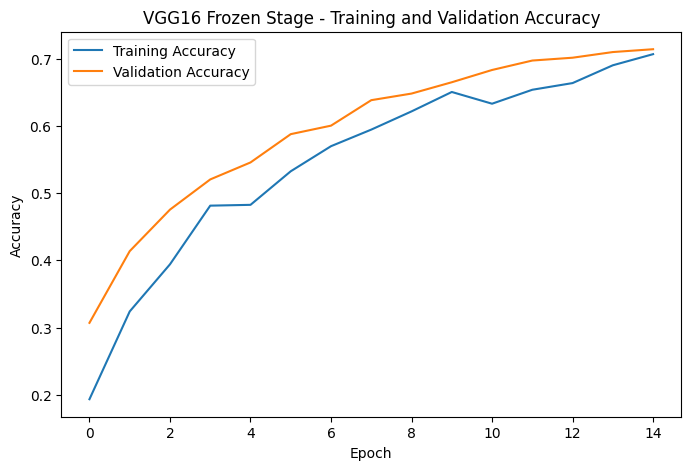

In [ ]:
# Plot frozen-stage VGG16 accuracy.
plt.figure(figsize=(8, 5))
plt.plot(
    history_vgg16_frozen.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_vgg16_frozen.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("VGG16 Frozen Stage - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


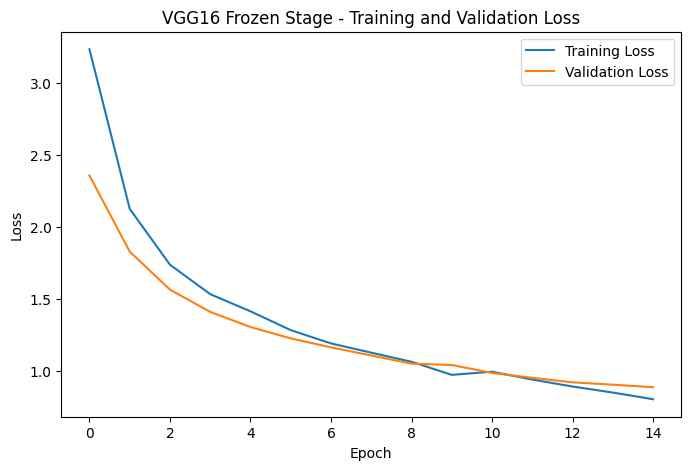

In [ ]:
# Plot frozen-stage VGG16 loss.
plt.figure(figsize=(8, 5))
plt.plot(
    history_vgg16_frozen.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_vgg16_frozen.history["val_loss"],
    label="Validation Loss"
)
plt.title("VGG16 Frozen Stage - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


The frozen VGG16 stage shows steady and stable learning across all 15 epochs.

Training accuracy increases from **19.36% to 70.66%**, while validation accuracy increases from **30.72% to 71.39%**. Training loss falls from **3.2344 to 0.8020**, and validation loss decreases consistently from **2.3568 to 0.8856**.

The training and validation curves remain close and improve together. Validation performance is even slightly higher than training performance for much of the run, which is reasonable because augmentation and Dropout are active during training but not during validation.

The best validation loss occurs at the final frozen-stage epoch, so the model has not shown a clear sign that the frozen classifier has stopped improving. The pretrained ImageNet features therefore provide a strong starting point, and the next stage tests whether adapting the highest VGG16 block can improve performance further.


### 6.3 Selective Fine-Tuning

Although the frozen VGG16 model already performs much better than the custom CNN, its highest-level visual features were originally learned for ImageNet rather than RealWaste.

To adapt these features more specifically to the waste-classification task, only `block5`, the highest convolutional block, is unfrozen.

Earlier VGG16 layers remain frozen because they mainly capture more general features such as edges, textures and simple shapes. The higher layers contain more task-specific representations and are therefore more suitable for selective fine-tuning.

A much smaller learning rate of 0.00001 is used to avoid making large changes to the useful pretrained weights.

Fine-tuning is allowed for up to 10 epochs, with validation-based callbacks used to stop or reduce the learning rate if performance stops improving.

In [ ]:
# Unfreeze only the highest VGG16 convolutional block.
base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block5")

print("Trainable VGG16 layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(" -", layer.name)

print()
print(
    "Trainable parameters during fine-tuning:",
    count_trainable_parameters(vgg16_model)
)

# Recompile after changing layer trainability.
vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_finetune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_vgg16_finetune = vgg16_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=vgg_finetune_callbacks,
    verbose=1
)

vgg_finetune_best_val_loss = min(
    history_vgg16_finetune.history["val_loss"]
)
vgg_finetune_best_val_accuracy = max(
    history_vgg16_finetune.history["val_accuracy"]
)


Trainable VGG16 layers:
 - block5_conv1
 - block5_conv2
 - block5_conv3
 - block5_pool

Trainable parameters during fine-tuning: 7146249
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 25s 218ms/step - accuracy: 0.7117 - loss: 0.7843 - val_accuracy: 0.7602 - val_loss: 0.8172 - learning_rate: 1.0000e-05
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 40s 213ms/step - accuracy: 0.7613 - loss: 0.6464 - val_accuracy: 0.7686 - val_loss: 0.7727 - learning_rate: 1.0000e-05
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 224ms/step - accuracy: 0.7877 - loss: 0.5750 - val_accuracy: 0.7896 - val_loss: 0.7473 - learning_rate: 1.0000e-05
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.8034 - loss: 0.5054 - val_accuracy: 0.8107 - val_loss: 0.7104 - learning_rate: 1.0000e-05
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 23s 224ms/step - accuracy: 0.8325 - loss: 0.4720 - val_accuracy: 0.8065 - val_loss: 0.7008 - learning_rate: 1.0000e-05
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0

### 6.4 Frozen vs Fine-Tuned VGG16

Fine-tuning produces a further improvement over the frozen feature extractor.

The best validation accuracy increases from **71.39% to 83.03%**, an improvement of **11.64 percentage points**. The lowest validation loss also improves from **0.8856 to 0.6487**.

During fine-tuning, training accuracy rises to **88.33%**. Validation accuracy reaches its highest value of **83.03% at epoch 7**, while the lowest validation loss occurs at **epoch 9**. The validation accuracy fluctuates slightly near the end while training accuracy continues to rise, which suggests the beginning of a train-validation gap rather than continued improvement at the same rate.

Because the fine-tuning callbacks monitor validation loss, the weights from **epoch 9** are restored. The final VGG16 stage is selected using validation performance only, so the test set remains untouched during model development.


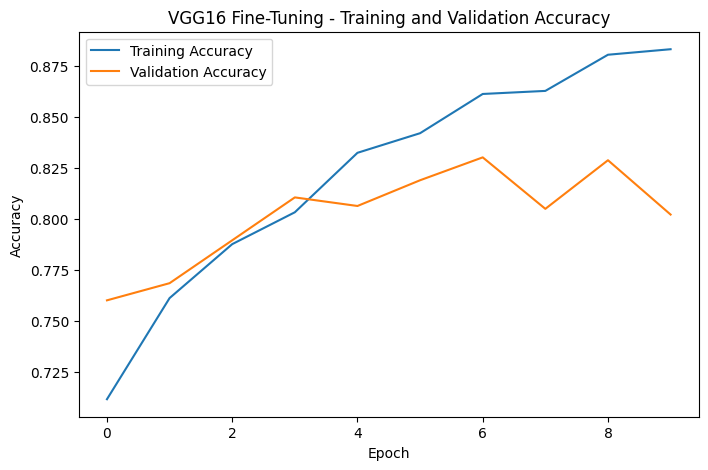

In [ ]:
# Plot fine-tuning accuracy.
plt.figure(figsize=(8, 5))
plt.plot(
    history_vgg16_finetune.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_vgg16_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("VGG16 Fine-Tuning - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


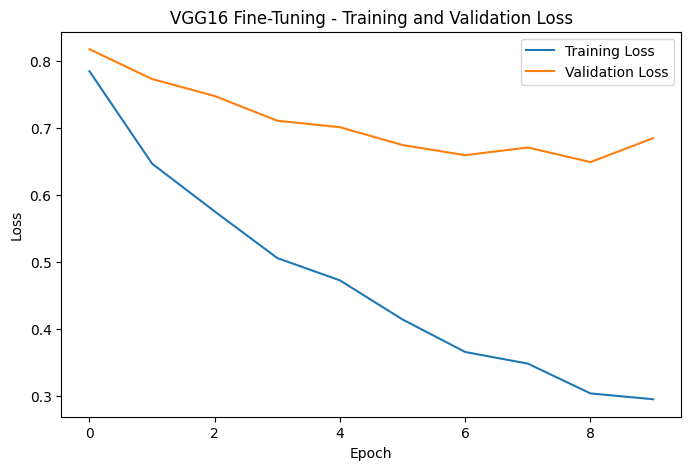

In [ ]:
# Plot fine-tuning loss.
plt.figure(figsize=(8, 5))
plt.plot(
    history_vgg16_finetune.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_vgg16_finetune.history["val_loss"],
    label="Validation Loss"
)
plt.title("VGG16 Fine-Tuning - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# Compare both VGG16 stages and retain the better validation configuration.
vgg_development_df = pd.DataFrame({
    "Stage": [
        "Frozen feature extractor",
        "Fine-tuned block5"
    ],
    "Best Validation Accuracy": [
        vgg_frozen_best_val_accuracy,
        vgg_finetune_best_val_accuracy
    ],
    "Best Validation Loss": [
        vgg_frozen_best_val_loss,
        vgg_finetune_best_val_loss
    ]
})

if vgg_finetune_best_val_loss < vgg_frozen_best_val_loss:
    selected_vgg_stage = "Fine-tuned block5"
    selected_vgg_best_val_accuracy = vgg_finetune_best_val_accuracy
    selected_vgg_best_val_loss = vgg_finetune_best_val_loss
else:
    selected_vgg_stage = "Frozen feature extractor"
    selected_vgg_best_val_accuracy = vgg_frozen_best_val_accuracy
    selected_vgg_best_val_loss = vgg_frozen_best_val_loss

    # Restore the best frozen-stage weights and freeze the base again.
    vgg16_model.load_weights(frozen_weights_path)
    base_model.trainable = False

    vgg16_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

print("Selected VGG16 stage:", selected_vgg_stage)
print(
    "Selected best validation loss:",
    f"{selected_vgg_best_val_loss:.4f}"
)
print(
    "Selected best validation accuracy:",
    f"{selected_vgg_best_val_accuracy:.4f}"
)

vgg_development_df.round(4)


Selected VGG16 stage: Fine-tuned block5
Selected best validation loss: 0.6487
Selected best validation accuracy: 0.8303


,Stage,Best Validation Accuracy,Best Validation Loss
0,Frozen feature extractor,0.7139,0.8856
1,Fine-tuned block5,0.8303,0.6487


The **fine-tuned `block5`** configuration is selected because it achieves the lower validation loss.

Compared with the frozen feature extractor, selective fine-tuning improves best validation accuracy by **11.64 percentage points** and reduces best validation loss by **0.2369**.

The improvement comes with a clear trade-off. In the frozen stage, only **66,825 of 14,781,513 parameters** are trainable. During fine-tuning, the number of trainable parameters increases to **7,146,249** because the layers in `block5` are allowed to update.

Therefore, fine-tuning requires substantially more trainable capacity, but the increase is justified in this experiment because it produces a clear validation improvement before the test set is used.


## 7. Final Model Evaluation and Comparison

The improved custom CNN and the validation-selected VGG16 model are now evaluated on the untouched test set.

The comparison uses several types of evidence:
- test accuracy and loss,
- precision, recall and F1-score,
- confusion matrices,
- per-class F1-scores,
- simple reference baselines,
- model complexity, and
- qualitative inspection of misclassified images.

Using several measures gives a more complete picture than relying on accuracy alone.


### 7.1 Test Accuracy, Loss and Simple Baselines

Both final models are evaluated on the same 713 unseen test images.

For context, two simple baselines are also included:
- uniform random guessing across nine classes, and
- always predicting the majority class.


In [ ]:
# Evaluate both final models on the unseen test set.
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    test_ds,
    verbose=1
)

vgg16_test_loss, vgg16_test_accuracy = vgg16_model.evaluate(
    test_ds,
    verbose=1
)

random_guess_accuracy = 1 / NUM_CLASSES
majority_baseline_accuracy = (
    test_df["label_id"]
    .value_counts(normalize=True)
    .max()
)

print("Improved Custom CNN")
print(f"Test Loss: {cnn_test_loss:.4f}")
print(f"Test Accuracy: {cnn_test_accuracy:.4f}")

print()
print("Selected VGG16")
print("Stage:", selected_vgg_stage)
print(f"Test Loss: {vgg16_test_loss:.4f}")
print(f"Test Accuracy: {vgg16_test_accuracy:.4f}")

print()
print("Reference Baselines")
print(f"Uniform random guess: {random_guess_accuracy:.4f}")
print(f"Majority-class baseline: {majority_baseline_accuracy:.4f}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.5105 - loss: 1.3633
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.8149 - loss: 0.6938
Improved Custom CNN
Test Loss: 1.3633
Test Accuracy: 0.5105

Selected VGG16
Stage: Fine-tuned block5
Test Loss: 0.6938
Test Accuracy: 0.8149

Reference Baselines
Uniform random guess: 0.1111
Majority-class baseline: 0.1935


Both final models perform well above the simple reference baselines.

The improved CNN reaches **51.05% test accuracy**, compared with **11.11%** for uniform random guessing and **19.35%** for always predicting the majority class. The selected VGG16 model reaches **81.49% test accuracy** with a lower test loss of **0.6938**, compared with **1.3633** for the improved CNN.

VGG16 therefore outperforms the improved CNN by **30.44 percentage points** on the unseen test set.

The test results are also close to the best validation accuracies: the improved CNN falls from 54.70% validation accuracy to 51.05% test accuracy, while VGG16 falls from 83.03% to 81.49%. These relatively small gaps suggest that the final validation-based model choices generalise reasonably well to unseen images.


### 7.2 Generate Predictions

Predicted probabilities are generated for every test image, and the class with the highest probability is used as the final predicted label.


In [ ]:
# Generate predictions for the same ordered test set.
y_true = test_df["label_id"].to_numpy()

cnn_probabilities = cnn_model.predict(
    test_ds,
    verbose=1
)
cnn_predictions = np.argmax(
    cnn_probabilities,
    axis=1
)

vgg16_probabilities = vgg16_model.predict(
    test_ds,
    verbose=1
)
vgg16_predictions = np.argmax(
    vgg16_probabilities,
    axis=1
)

print("Number of true labels:", len(y_true))
print("Improved CNN predictions:", len(cnn_predictions))
print("VGG16 predictions:", len(vgg16_predictions))


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step
Number of true labels: 713
Improved CNN predictions: 713
VGG16 predictions: 713


### 7.3 Classification Reports

Accuracy gives the overall proportion of correct predictions, but it can hide weak performance on individual classes. Precision, recall and F1-score are therefore examined for every waste category, together with macro and weighted averages.


In [ ]:
# Detailed per-class classification reports.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

print("IMPROVED CUSTOM CNN CLASSIFICATION REPORT")
print()
print(
    classification_report(
        y_true,
        cnn_predictions,
        target_names=class_names,
        zero_division=0
    )
)

print("SELECTED VGG16 CLASSIFICATION REPORT")
print()
print(
    classification_report(
        y_true,
        vgg16_predictions,
        target_names=class_names,
        zero_division=0
    )
)


IMPROVED CUSTOM CNN CLASSIFICATION REPORT

                     precision    recall  f1-score   support

          Cardboard       0.40      0.86      0.54        69
      Food Organics       0.45      0.45      0.45        62
              Glass       0.97      0.59      0.73        63
              Metal       0.55      0.57      0.56       118
Miscellaneous Trash       0.30      0.23      0.26        75
              Paper       0.89      0.32      0.47        75
            Plastic       0.45      0.62      0.52       138
      Textile Trash       0.51      0.44      0.47        48
         Vegetation       0.81      0.40      0.54        65

           accuracy                           0.51       713
          macro avg       0.59      0.50      0.51       713
       weighted avg       0.58      0.51      0.51       713

SELECTED VGG16 CLASSIFICATION REPORT

                     precision    recall  f1-score   support

          Cardboard       0.74      0.88      0.81        69


The classification reports show that the performance difference is not limited to overall accuracy.

For the improved CNN, **Glass is the strongest class (F1 = 0.733)**, while **Miscellaneous Trash is the weakest (F1 = 0.258)**. The model is also uneven across precision and recall. For example, Cardboard has **0.86 recall but only 0.40 precision**, meaning that it identifies most Cardboard images but also incorrectly assigns many non-Cardboard images to that class. Paper shows the opposite pattern, with **0.89 precision but only 0.32 recall**, so its Paper predictions are usually correct but many true Paper images are missed.

VGG16 is much more balanced. Its class F1-scores range from **0.652 for Miscellaneous Trash to 0.881 for Vegetation**. Its macro F1-score is **0.8180** and its weighted F1-score is **0.8125**, both close to the overall test accuracy of 81.49%. This indicates that the strong result is distributed across the classes rather than being caused only by the larger categories.


### 7.4 Confusion Matrices

The confusion matrices provide a class-by-class view of the predictions. A strong model should show a clear diagonal, while larger off-diagonal values reveal specific categories that are being confused.


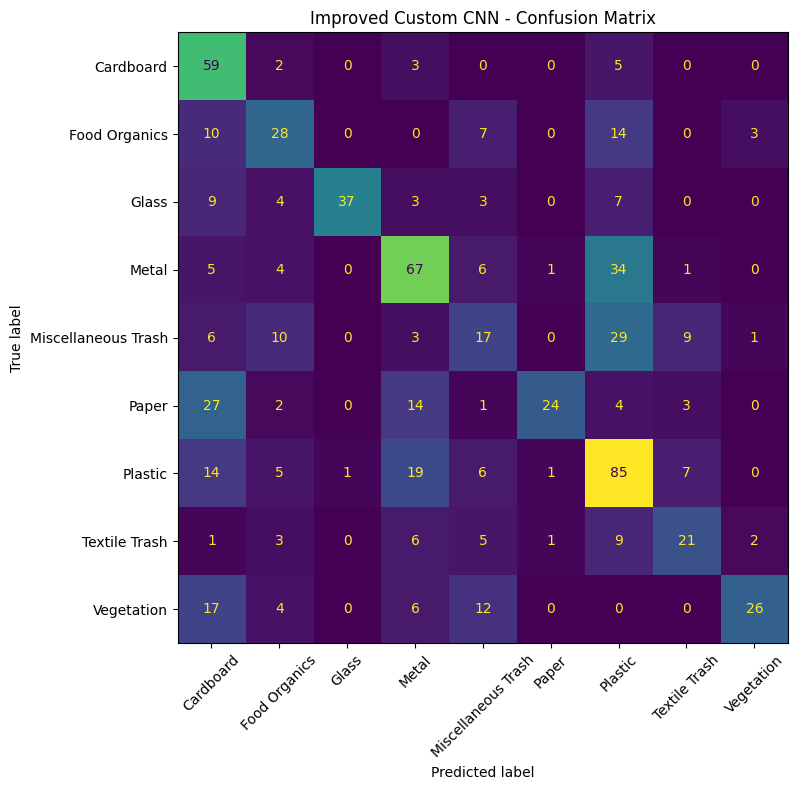

In [ ]:
# Improved CNN confusion matrix.
cnn_cm = confusion_matrix(
    y_true,
    cnn_predictions
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=class_names
).plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)
plt.title("Improved Custom CNN - Confusion Matrix")
plt.tight_layout()
plt.show()


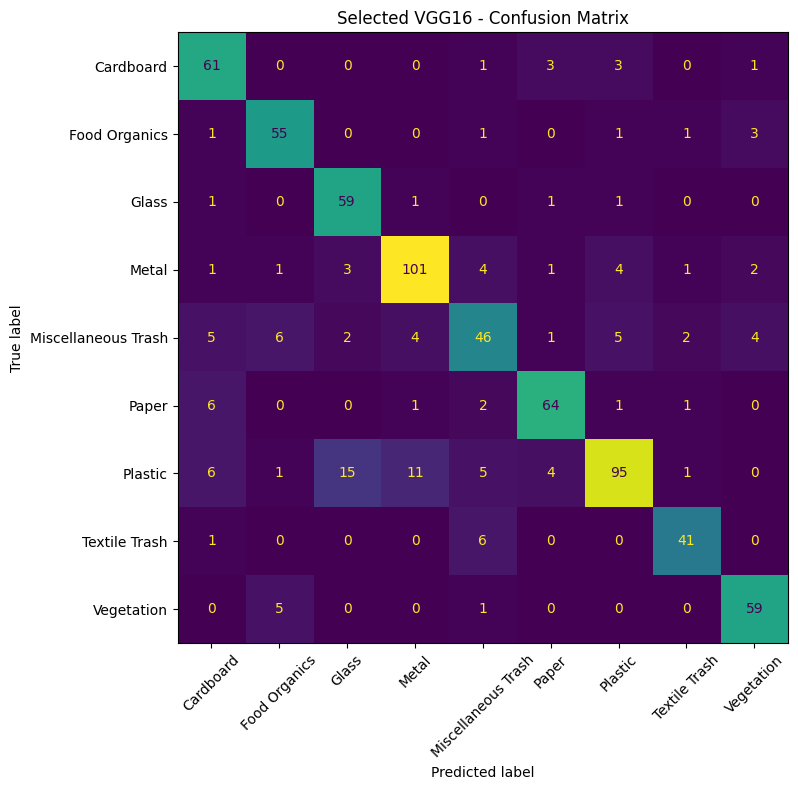

In [ ]:
# Selected VGG16 confusion matrix.
vgg16_cm = confusion_matrix(
    y_true,
    vgg16_predictions
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=vgg16_cm,
    display_labels=class_names
).plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)
plt.title("Selected VGG16 - Confusion Matrix")
plt.tight_layout()
plt.show()


The confusion matrices reinforce the classification-report results. The improved CNN has more errors spread across several classes, while VGG16 shows a much stronger diagonal, meaning correct predictions are more consistently distributed across the nine categories.

The exact largest confusion pairs are examined in the next section.


### 7.5 Per-Class F1-Score Comparison

F1-score balances precision and recall. Comparing it class by class shows whether one model is consistently stronger across the dataset or only better for a small number of categories.


In [ ]:
# Convert the classification reports to dictionaries.
cnn_report = classification_report(
    y_true,
    cnn_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

vgg16_report = classification_report(
    y_true,
    vgg16_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_f1 = pd.DataFrame({
    "Class": class_names,
    "Improved CNN F1": [
        cnn_report[class_name]["f1-score"]
        for class_name in class_names
    ],
    "VGG16 F1": [
        vgg16_report[class_name]["f1-score"]
        for class_name in class_names
    ]
})

per_class_f1["F1 Difference (VGG16 - CNN)"] = (
    per_class_f1["VGG16 F1"]
    - per_class_f1["Improved CNN F1"]
)

per_class_f1.round(3)


,Class,Improved CNN F1,VGG16 F1,F1 Difference (VGG16 - CNN)
0,Cardboard,0.544,0.808,0.264
1,Food Organics,0.452,0.846,0.395
2,Glass,0.733,0.831,0.098
3,Metal,0.561,0.856,0.295
4,Miscellaneous Trash,0.258,0.652,0.395
5,Paper,0.471,0.859,0.388
6,Plastic,0.523,0.766,0.243
7,Textile Trash,0.472,0.863,0.391
8,Vegetation,0.536,0.881,0.345


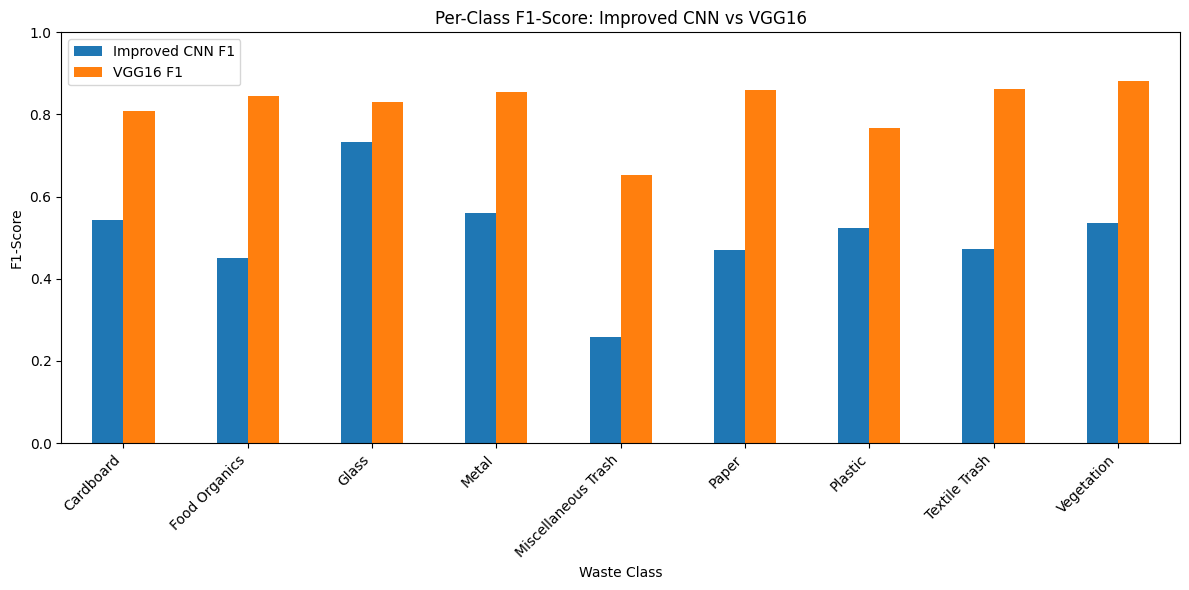

In [ ]:
# Plot per-class F1-scores for both final models.
f1_plot_df = per_class_f1.set_index("Class")[[
    "Improved CNN F1",
    "VGG16 F1"
]]

f1_plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Per-Class F1-Score: Improved CNN vs VGG16")
plt.xlabel("Waste Class")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


VGG16 achieves a higher F1-score than the improved CNN for **every one of the nine classes**.

The smallest improvement is for Glass, where F1 increases from **0.733 to 0.831**. The largest improvements are seen for **Food Organics** and **Miscellaneous Trash**, both improving by about **0.395 F1**. Large gains are also seen for Paper and Textile Trash.

This shows that VGG16's advantage is broad across the dataset rather than being caused by only one or two classes.


### 7.6 Most Common Misclassifications

The confusion matrices show the overall pattern of predictions, but the table below identifies the specific true-class → predicted-class errors that occur most frequently.

This makes it easier to see which waste categories the models have the most difficulty separating.

In [ ]:
# Extract the most common true-class -> predicted-class misclassifications.
from IPython.display import display


def top_misclassifications(cm, labels, top_n=8):
    rows = []

    for true_index in range(len(labels)):
        for predicted_index in range(len(labels)):

            # Ignore correct predictions on the diagonal.
            if true_index == predicted_index:
                continue

            count = int(
                cm[true_index, predicted_index]
            )

            if count > 0:
                rows.append({
                    "True Class": labels[true_index],
                    "Predicted Class": labels[predicted_index],
                    "Number of Images": count
                })

    if not rows:
        return pd.DataFrame(
            columns=[
                "True Class",
                "Predicted Class",
                "Number of Images"
            ]
        )

    return (
        pd.DataFrame(rows)
        .sort_values(
            "Number of Images",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


print(
    "Improved CNN - Most Common Misclassifications"
)

display(
    top_misclassifications(
        cnn_cm,
        class_names
    )
)


print(
    "Selected VGG16 - Most Common Misclassifications"
)

display(
    top_misclassifications(
        vgg16_cm,
        class_names
    )
)

Improved CNN - Most Common Misclassifications


,True Class,Predicted Class,Number of Images
0,Metal,Plastic,34
1,Miscellaneous Trash,Plastic,29
2,Paper,Cardboard,27
3,Plastic,Metal,19
4,Vegetation,Cardboard,17
5,Food Organics,Plastic,14
6,Paper,Metal,14
7,Plastic,Cardboard,14


Selected VGG16 - Most Common Misclassifications


,True Class,Predicted Class,Number of Images
0,Plastic,Glass,15
1,Plastic,Metal,11
2,Miscellaneous Trash,Food Organics,6
3,Plastic,Cardboard,6
4,Paper,Cardboard,6
5,Textile Trash,Miscellaneous Trash,6
6,Miscellaneous Trash,Plastic,5
7,Miscellaneous Trash,Cardboard,5


The improved CNN makes substantially more repeated misclassifications than VGG16.

Its most frequent error is **Metal → Plastic (34 images)**, followed by **Miscellaneous Trash → Plastic (29)** and **Paper → Cardboard (27)**. These patterns are consistent with the class-level metrics: the CNN tends to over-predict some broad visual categories such as Plastic and Cardboard.

The selected VGG16 model has much smaller repeated error counts. Its largest misclassification is **Plastic → Glass (15 images)**, followed by **Plastic → Metal (11)**. This shows that Plastic remains one of the more difficult classes even for the stronger model, likely because plastic objects can vary widely in shape and transparency and may visually resemble Glass or Metal.

Miscellaneous Trash also appears repeatedly among VGG16's errors, which is reasonable because this class contains a visually diverse collection of objects rather than one consistent material or appearance.


### 7.7 Qualitative Error Analysis

Numerical metrics show how often the models are wrong, but inspecting individual mistakes can help explain why.

The examples below show several high-confidence incorrect predictions, together with the true class and the model's confidence.


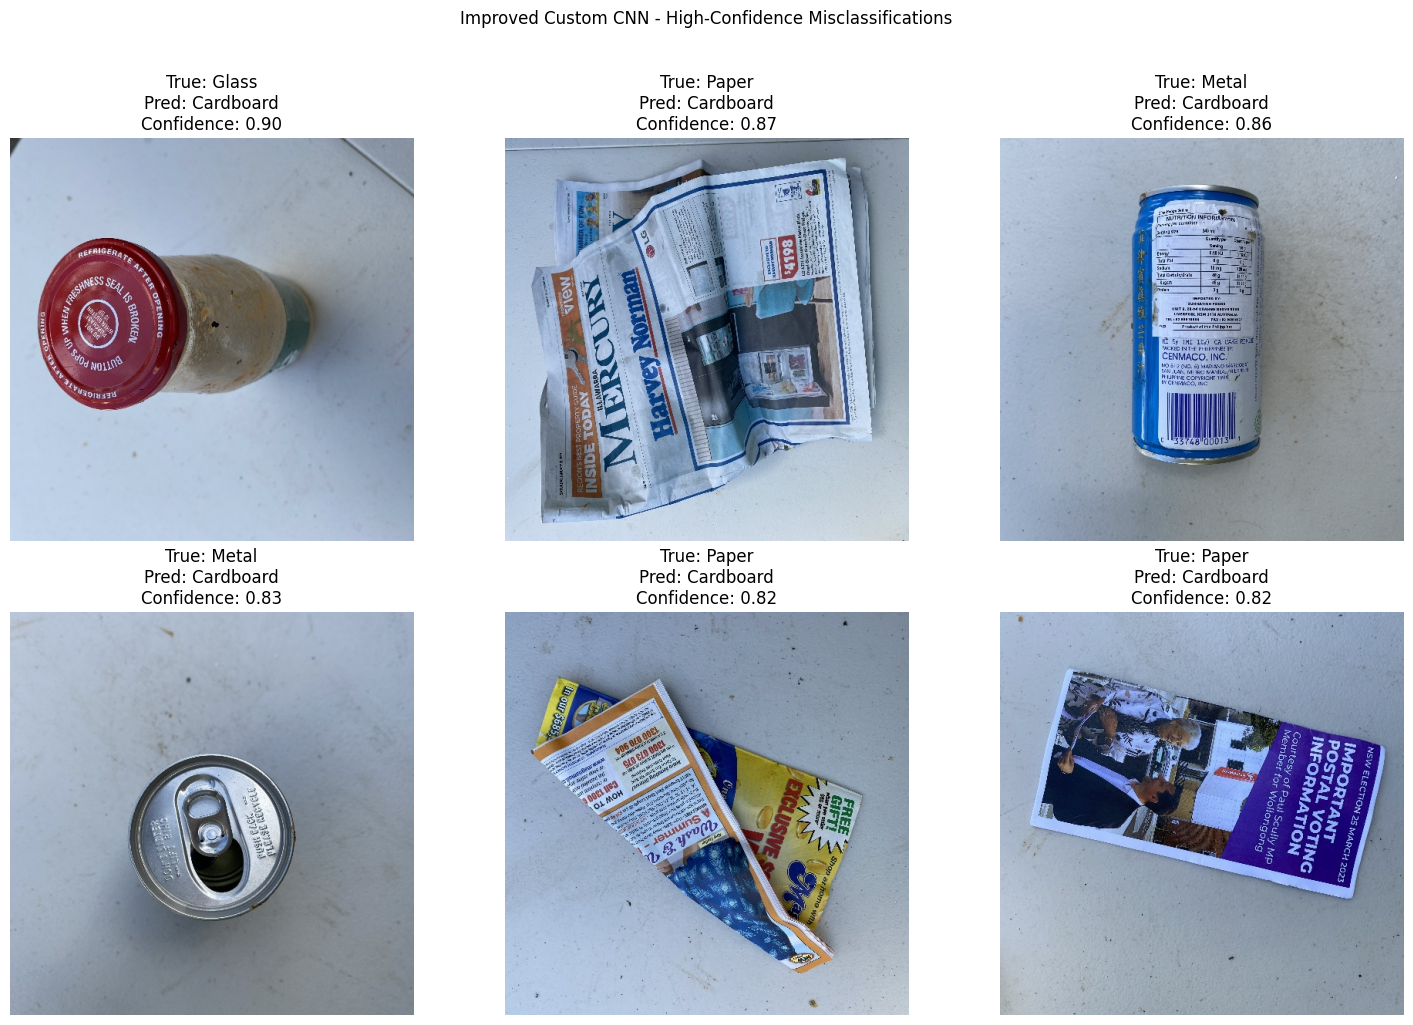

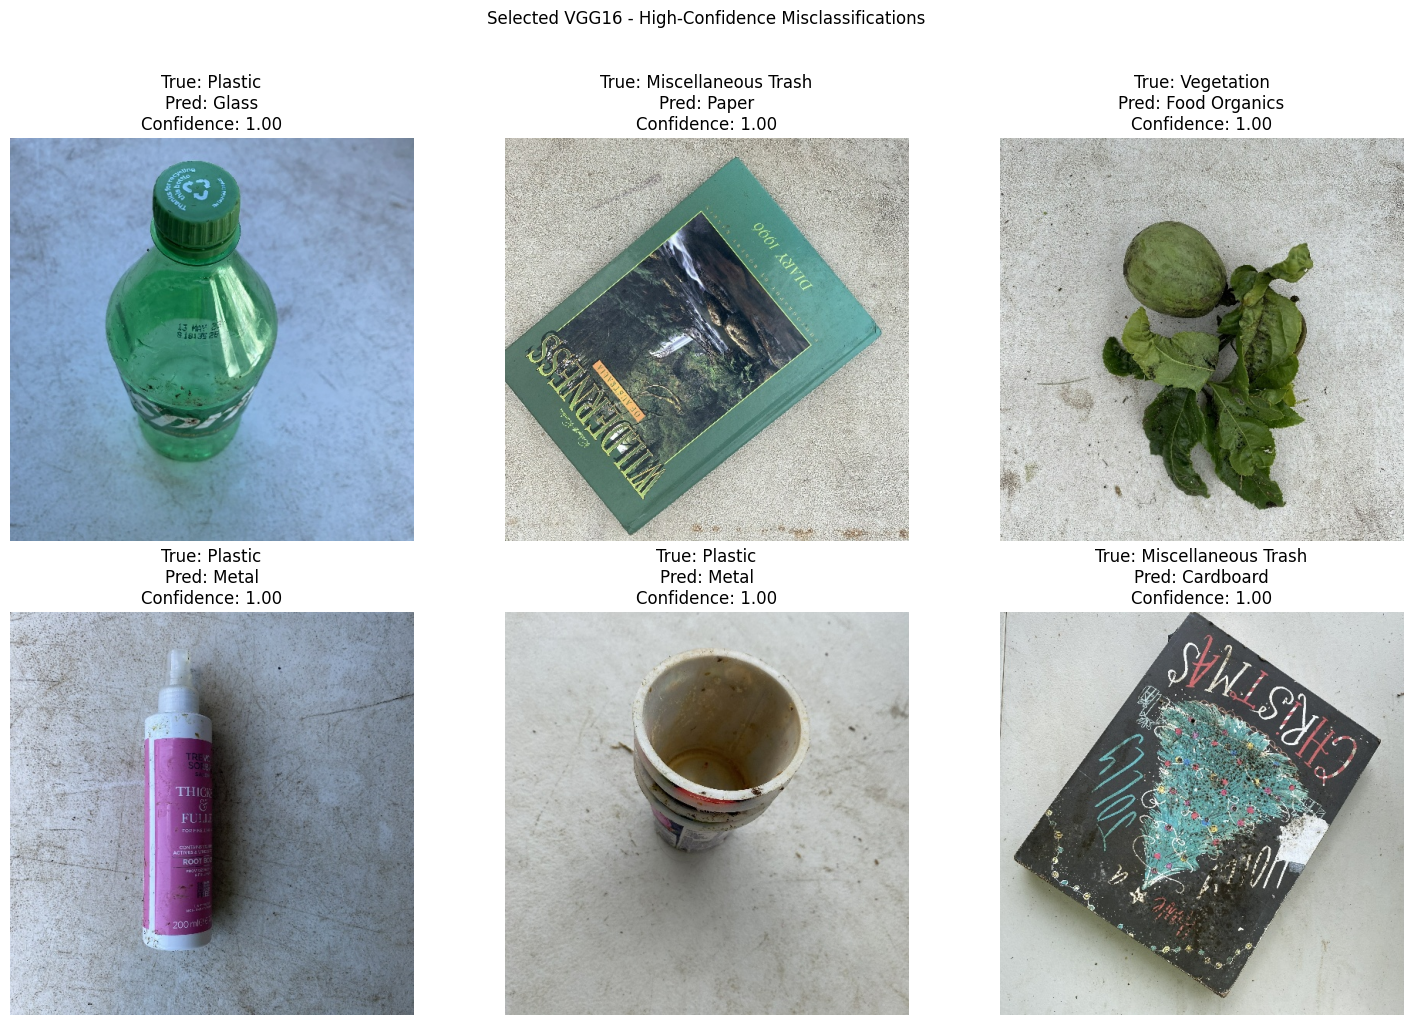

In [ ]:
# Display a sample of misclassified images for qualitative analysis.
def show_misclassified_examples(
    predictions,
    probabilities,
    model_name,
    n=6
):
    test_reset = test_df.reset_index(drop=True)
    wrong_indices = np.where(
        predictions != y_true
    )[0]

    if len(wrong_indices) == 0:
        print(f"{model_name}: no misclassified test images.")
        return

    # Show the highest-confidence mistakes first.
    wrong_confidences = probabilities[
        wrong_indices
    ].max(axis=1)

    sorted_wrong = wrong_indices[
        np.argsort(wrong_confidences)[::-1]
    ][:n]

    cols = 3
    rows = int(np.ceil(len(sorted_wrong) / cols))

    plt.figure(figsize=(15, 5 * rows))

    for plot_index, sample_index in enumerate(
        sorted_wrong,
        start=1
    ):
        image_path = test_reset.loc[
            sample_index,
            "filepath"
        ]

        image = Image.open(image_path).convert("RGB")

        true_name = class_names[y_true[sample_index]]
        predicted_name = class_names[
            predictions[sample_index]
        ]
        confidence = probabilities[
            sample_index
        ].max()

        plt.subplot(rows, cols, plot_index)
        plt.imshow(image)
        plt.title(
            f"True: {true_name}\n"
            f"Pred: {predicted_name}\n"
            f"Confidence: {confidence:.2f}"
        )
        plt.axis("off")

    plt.suptitle(
        f"{model_name} - High-Confidence Misclassifications",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

show_misclassified_examples(
    cnn_predictions,
    cnn_probabilities,
    "Improved Custom CNN"
)

show_misclassified_examples(
    vgg16_predictions,
    vgg16_probabilities,
    "Selected VGG16"
)


The qualitative examples support the numerical results.

For the improved CNN, all six highest-confidence mistakes shown here are predicted as **Cardboard**, even though the true images include Glass, Paper and Metal. The confidence values are still high (about 0.82–0.90). This matches the classification report, where Cardboard has high recall but much lower precision, and shows that the CNN has learned an overly broad decision boundary for this class.

VGG16 makes fewer errors overall, but its highest-confidence mistakes reveal some understandable visual ambiguity. A Plastic bottle is predicted as Glass, other Plastic containers are predicted as Metal, Vegetation is predicted as Food Organics, and visually mixed Miscellaneous Trash examples are assigned to Paper or Cardboard.

Several of these incorrect VGG16 predictions have confidence values displayed as 1.00. This shows that model confidence is not the same as correctness and suggests that probability calibration could be investigated if reliable confidence estimates were important in a real deployment.


### 7.8 Overall Performance and Complexity Comparison

The final comparison combines predictive performance with model size.

Macro metrics give each class equal importance, while weighted F1 also reflects the class frequencies. Total and trainable parameter counts show the trade-off between the compact scratch CNN and the larger pretrained VGG16 model.


In [ ]:
# Calculate overall metrics for both final models.
cnn_precision, cnn_recall, cnn_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        cnn_predictions,
        average="macro",
        zero_division=0
    )
)
cnn_weighted_f1 = precision_recall_fscore_support(
    y_true,
    cnn_predictions,
    average="weighted",
    zero_division=0
)[2]

vgg16_precision, vgg16_recall, vgg16_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        vgg16_predictions,
        average="macro",
        zero_division=0
    )
)
vgg16_weighted_f1 = precision_recall_fscore_support(
    y_true,
    vgg16_predictions,
    average="weighted",
    zero_division=0
)[2]

cnn_best_val_accuracy = max(
    history_cnn.history["val_accuracy"]
)

comparison_df = pd.DataFrame({
    "Model": [
        "Improved Custom CNN",
        f"VGG16 ({selected_vgg_stage})"
    ],
    "Total Parameters": [
        cnn_model.count_params(),
        vgg16_model.count_params()
    ],
    "Trainable Parameters": [
        count_trainable_parameters(cnn_model),
        count_trainable_parameters(vgg16_model)
    ],
    "Best Validation Accuracy": [
        cnn_best_val_accuracy,
        selected_vgg_best_val_accuracy
    ],
    "Test Loss": [
        cnn_test_loss,
        vgg16_test_loss
    ],
    "Test Accuracy": [
        cnn_test_accuracy,
        vgg16_test_accuracy
    ],
    "Macro Precision": [
        cnn_precision,
        vgg16_precision
    ],
    "Macro Recall": [
        cnn_recall,
        vgg16_recall
    ],
    "Macro F1": [
        cnn_f1,
        vgg16_f1
    ],
    "Weighted F1": [
        cnn_weighted_f1,
        vgg16_weighted_f1
    ]
})

comparison_df.round(4)


,Model,Total Parameters,Trainable Parameters,Best Validation Accuracy,Test Loss,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Improved Custom CNN,571881,570665,0.5470,1.3633,0.5105,0.5938,0.4958,0.5053,0.5079
1,VGG16 (Fine-tuned block5),14781513,7146249,0.8303,0.6938,0.8149,0.8120,0.8312,0.8180,0.8125


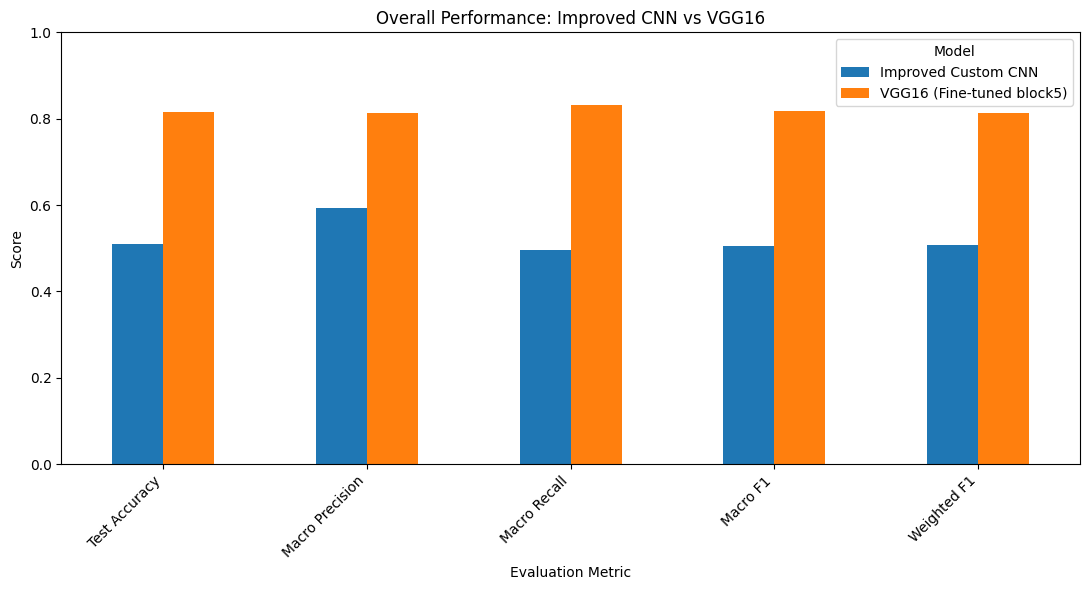

In [ ]:
# Visualise the main final test metrics.
metric_comparison = comparison_df.set_index(
    "Model"
)[[
    "Test Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]]

metric_comparison.T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Overall Performance: Improved CNN vs VGG16")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


The overall comparison highlights the main trade-off between the two final models.

The improved CNN is very compact, with **571,881 total parameters**, while VGG16 contains **14,781,513**. However, the larger pretrained model achieves much stronger validation accuracy, test accuracy and both macro and weighted F1-scores.

The improved CNN therefore offers lower model complexity, while VGG16 provides the stronger classification performance. For this task, the performance gain from transfer learning is large enough to justify the additional model size.


### 7.9 Final Comparison Summary

The next cell collects the main results into one concise summary.


In [ ]:
# Generate a result-based final summary.
if vgg16_test_accuracy >= cnn_test_accuracy:
    higher_accuracy_model = "VGG16"
else:
    higher_accuracy_model = "Improved Custom CNN"

if vgg16_f1 >= cnn_f1:
    higher_macro_f1_model = "VGG16"
else:
    higher_macro_f1_model = "Improved Custom CNN"

vgg_weakest_row = per_class_f1.loc[
    per_class_f1["VGG16 F1"].idxmin()
]
vgg_strongest_row = per_class_f1.loc[
    per_class_f1["VGG16 F1"].idxmax()
]

cnn_weakest_row = per_class_f1.loc[
    per_class_f1["Improved CNN F1"].idxmin()
]
cnn_strongest_row = per_class_f1.loc[
    per_class_f1["Improved CNN F1"].idxmax()
]

print("FINAL COMPARISON SUMMARY")
print("-" * 60)
print(
    f"Improved CNN test accuracy: {cnn_test_accuracy:.2%} | "
    f"macro F1: {cnn_f1:.4f}"
)
print(
    f"VGG16 test accuracy: {vgg16_test_accuracy:.2%} | "
    f"macro F1: {vgg16_f1:.4f}"
)
print(
    f"VGG16 configuration selected using validation data: "
    f"{selected_vgg_stage}"
)
print(
    f"Higher test accuracy: {higher_accuracy_model}"
)
print(
    f"Higher macro F1: {higher_macro_f1_model}"
)
print(
    f"Improved CNN strongest class: "
    f"{cnn_strongest_row['Class']} "
    f"(F1={cnn_strongest_row['Improved CNN F1']:.3f})"
)
print(
    f"Improved CNN weakest class: "
    f"{cnn_weakest_row['Class']} "
    f"(F1={cnn_weakest_row['Improved CNN F1']:.3f})"
)
print(
    f"VGG16 strongest class: "
    f"{vgg_strongest_row['Class']} "
    f"(F1={vgg_strongest_row['VGG16 F1']:.3f})"
)
print(
    f"VGG16 weakest class: "
    f"{vgg_weakest_row['Class']} "
    f"(F1={vgg_weakest_row['VGG16 F1']:.3f})"
)
print(
    f"Random-guess baseline: {random_guess_accuracy:.2%} | "
    f"Majority-class baseline: {majority_baseline_accuracy:.2%}"
)


FINAL COMPARISON SUMMARY
------------------------------------------------------------
Improved CNN test accuracy: 51.05% | macro F1: 0.5053
VGG16 test accuracy: 81.49% | macro F1: 0.8180
VGG16 configuration selected using validation data: Fine-tuned block5
Higher test accuracy: VGG16
Higher macro F1: VGG16
Improved CNN strongest class: Glass (F1=0.733)
Improved CNN weakest class: Miscellaneous Trash (F1=0.258)
VGG16 strongest class: Vegetation (F1=0.881)
VGG16 weakest class: Miscellaneous Trash (F1=0.652)
Random-guess baseline: 11.11% | Majority-class baseline: 19.35%


### 7.10 Discussion, Trade-offs and Remaining Improvements

The final results show a clear advantage for transfer learning on the RealWaste dataset.

The **improved custom CNN reaches 51.05% test accuracy with a macro F1-score of 0.5053**, while the **fine-tuned VGG16 reaches 81.49% test accuracy with a macro F1-score of 0.8180**. VGG16 therefore improves test accuracy by **30.44 percentage points** and gives substantially stronger class-balanced performance.

The scratch-CNN development is still a useful optimisation result. Replacing the parameter-heavy `Flatten` design reduces the model from about **12.94 million parameters to 0.57 million**, a 95.58% reduction, while best validation accuracy improves from **19.21% to 54.70%**. This demonstrates that the original architecture was inefficient and that the redesign made the from-scratch model both smaller and more effective.

The VGG16 experiment shows the benefit of pretrained features on a relatively small image dataset. The frozen feature extractor already reaches **71.39% best validation accuracy**, and selective fine-tuning increases this to **83.03%**. The final test accuracy of **81.49%** remains close to the validation result, suggesting that the selected configuration generalises well to unseen images.

The class-level metrics show the same pattern. VGG16 achieves a higher F1-score than the improved CNN for **all nine classes**. The CNN performs best on Glass but struggles particularly with Miscellaneous Trash, while VGG16 is much more balanced and reaches class F1-scores from **0.652 to 0.881**.

The remaining VGG16 errors are concentrated mainly around visually overlapping or heterogeneous categories. Plastic is frequently misclassified as Glass or Metal, while Miscellaneous Trash is spread across several other categories. The qualitative examples support this interpretation and also show that some wrong predictions can still be made with very high confidence.

There is an important complexity trade-off. The improved CNN contains only about **0.57 million total parameters**, whereas the final VGG16 model contains about **14.78 million**. During fine-tuning, approximately **7.15 million VGG16 parameters** are trainable. The custom CNN is therefore much more compact, but VGG16 provides a large improvement in predictive performance.

Future improvements should focus on the remaining error patterns rather than simply increasing the number of epochs. Possible experiments include more targeted augmentation for difficult classes, collecting additional examples for visually diverse classes such as Miscellaneous Trash, testing alternative scratch-CNN capacities, and comparing VGG16 with a more modern pretrained architecture such as EfficientNet. Any further model-selection decisions should continue to use training and validation data, with the test set reserved for final evaluation.


## References

[1] UCI Machine Learning Repository. (n.d.-b). https://archive.ics.uci.edu/dataset/908/realwaste

[2] Lecture 1-3, 5 Slides

[3] Practical 1-3, 5 Notebooks

[4] Matplotlib Development Team, “Matplotlib Documentation.”
Available: https://matplotlib.org/stable/

[5] Scikit-learn Developers, “Scikit-learn Documentation.”
Available: https://scikit-learn.org/stable/

[6] GeeksforGeeks. (2022, March). Convolutional Neural Network (CNN) in Tensorflow. GeeksforGeeks. https://www.geeksforgeeks.org/deep-learning/convolutional-neural-network-cnn-in-tensorflow/

[7] Thakur, R. (2023, March 9). Beginners Guide to VGG16 Implementation in Keras | Built In. Builtin.Com. https://builtin.com/machine-learning/vgg16

[8] TensorFlow, “TensorFlow Keras Documentation.”
Available: https://www.tensorflow.org/api_docs/python/tf/keras

[9] Google. (2024). Overfitting. Google for Developers. https://developers.google.com/machine-learning/crash-course/overfitting/overfitting

[10] Scikit Learn. (2025). 3.3. Metrics and scoring: quantifying the quality of predictions — scikit-learn 0.22.1 documentation. Scikit-Learn.Org. https://scikit-learn.org/stable/modules/model_evaluation.html

[11] Transfer learning with a pretrained ConvNet | TensorFlow Core. (n.d.). TensorFlow. Retrieved August 28, 2026, from https://www.tensorflow.org/tutorials/images/transfer_learning

[12] Awan, A. A. (2022, November). A Complete Guide to Data Augmentation. DataCamp. https://www.datacamp.com/tutorial/complete-guide-data-augmentation

[13] A. Rosebrock, “Detect and remove duplicate images from a dataset for deep learning,” PyImageSearch, 2020.
Available: https://pyimagesearch.com/2020/04/20/detect-and-remove-duplicate-images-from-a-dataset-for-deep-learning/

[14] Stack Overflow, “Python Script to Detect Broken Images,” 2017.
Available: https://stackoverflow.com/questions/46854496/python-script-to-detect-broken-images